In [1]:
print("TESYT")

TESYT


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory

from pathlib import Path
import re

NVIDIA A100-PCIE-40GB
59
[0.3471540113290151, 0.37679639081160227, 0.3519435640838411, 0.34978981051180097, 0.3615421718358994, 0.3591589789920383, 0.36024816162056394, 0.40040201584498086, 0.38472501198450726, 0.35728497684001925, 0.35172327273421816, 0.35201857851611246, 0.38355301797389985, 0.3622621112399631, 0.3457468322912852, 0.35758534318870966, 0.43086479922135673, 0.36342686004108854, 0.35972914271884493, 0.35728497684001925, 0.34818792449103464, 0.437593792213334, 0.401957245932685, 0.3512962078385883, 0.3548413059446547, 0.3565374657842848, 0.3495098380247752, 0.3551261584626304, 0.3542882402737935, 0.3500212534930971, 0.353288133541743, 0.3591589789920383, 0.3511568013827006, 0.34688732385635374, 0.3582581249872843, 0.3743463057279587, 0.3750533319181866, 0.3752559218141768, 0.35244237866666583, 0.35509695066346064, 0.36159439232614304, 0.34937302264902326, 0.4094132186969121, 0.38472501198450726, 0.3607332523001565, 0.3472784138388104, 0.36590200384457905, 0.3527315845754

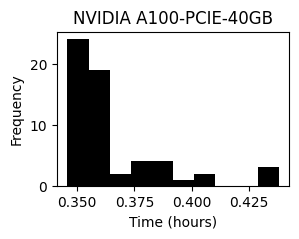

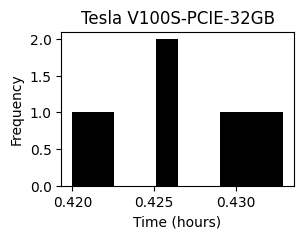

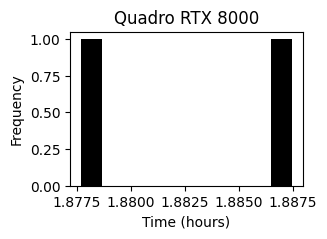

In [3]:
files = list(Path(".").glob("joint/static-smw/rs*/slurm*"))

time_results = {}

for file in files:

    with open(file, "r") as f:
        lines = f.readlines()
        for line in lines:
            matches = re.findall(r"^\|\s*\d+\s+(.+?)\s{2,}(?:On|Off)\s+\|", line, re.MULTILINE)
            if len(matches) > 0:
                gpu_name = matches[0]
                break;

    p = Path(file.parent / "DONE")
    try:
        with p.open() as f:
            pass;
    except FileNotFoundError:
        continue;

    p = Path(file.parent / "energy_traj.txt")
    try:
        with p.open() as f:
            traj_len = sum(1 for _ in f)
    except FileNotFoundError:
        continue;

    p = Path(file.parent / "time.txt")
    try:
        with p.open() as f:
            time = float(f.read().strip()) # time in hours
    except FileNotFoundError:
        continue;
    
    if traj_len < 1000:
        continue;

    if time_results.get(gpu_name) is None:
        time_results[gpu_name] = []

    time_results[gpu_name].append(time)

for gpu_name, times in time_results.items():
    print(gpu_name)
    print(len(times))
    print(times)
    print()

for gpu_name, times in time_results.items():
    plt.figure(figsize=(3,2))
    plt.title(gpu_name)
    plt.hist(times, color='black')
    plt.xlabel("Time (hours)")
    plt.ylabel("Frequency")
    plt.show()